In [1]:
import pandas as pd

In [2]:
data=pd.read_excel("/content/suicide data.xlsx")

In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

# Download necessary NLTK data
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [4]:
# Ensure all entries in the 'text' column are strings
data['text'] = data['text'].astype(str)

# Updated preprocessing function
def preprocess_text(text):
    # Handle non-string or NaN values gracefully
    if not isinstance(text, str):
        return ''
    # Convert to lowercase
    text = text.lower()
    # Remove special characters, numbers, and punctuation
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize and remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]
    # Lemmatize each word
    words = [lemmatizer.lemmatize(word) for word in words]
    # Join back into a single string
    return ' '.join(words)

# Apply preprocessing to the 'text' column
data['cleaned_text'] = data['text'].apply(preprocess_text)

# Encode target labels
encoder = LabelEncoder()
data['encoded_class'] = encoder.fit_transform(data['class'])

# Split the data into training and test sets
X = data['cleaned_text']
y = data['encoded_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train).toarray()
X_test_tfidf = tfidf_vectorizer.transform(X_test).toarray()

# Display results
print("Text preprocessing complete.")
print(f"Cleaned Text Example:\n{data['cleaned_text'].iloc[0]}")
print(f"X_train shape: {X_train_tfidf.shape}")
print(f"X_test shape: {X_test_tfidf.shape}")


Text preprocessing complete.
Cleaned Text Example:
ex wife threatening suiciderecently left wife good cheated twice lied much decided refuse go back day ago began threatening suicide tirelessly spent paat day talking keep hesitating want believe ill come back know lot people threaten order get way happens really supposed handle death hand still love wife cannot deal getting cheated constantly feeling insecure im worried today may day hope much doesnt happen
X_train shape: (185636, 5000)
X_test shape: (46409, 5000)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import pickle

# Dictionary to store models and results
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)  # Train the model

    # Save the trained model
    with open(f'{name.replace(" ", "_")}_model.pkl', 'wb') as f:
        pickle.dump(model, f)

    # Predict on the test set
    y_pred = model.predict(X_test_tfidf)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy * 100:.2f}%")
    print(classification_report(y_test, y_pred))

    # Store results
    results[name] = accuracy

# Display results
print("\nSummary of Model Accuracies:")
for name, acc in results.items():
    print(f"{name}: {acc * 100:.2f}%")


Training Logistic Regression...
Logistic Regression Accuracy: 93.51%
              precision    recall  f1-score   support

           0       0.93      0.94      0.94     23238
           1       0.94      0.93      0.93     23171

    accuracy                           0.94     46409
   macro avg       0.94      0.94      0.94     46409
weighted avg       0.94      0.94      0.94     46409

Training Naive Bayes...
Naive Bayes Accuracy: 90.37%
              precision    recall  f1-score   support

           0       0.94      0.86      0.90     23238
           1       0.87      0.95      0.91     23171

    accuracy                           0.90     46409
   macro avg       0.91      0.90      0.90     46409
weighted avg       0.91      0.90      0.90     46409


Summary of Model Accuracies:
Logistic Regression: 93.51%
Naive Bayes: 90.37%


Training Logistic Regression...
Confusion Matrix for Logistic Regression:
[[21902  1336]
 [ 1677 21494]]


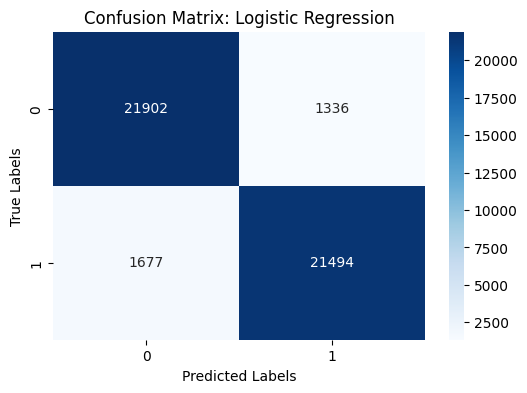

Logistic Regression AUC: 0.98


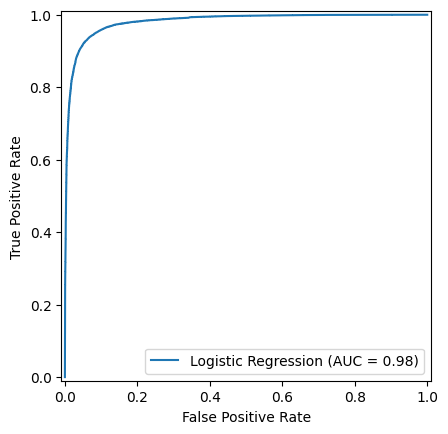

Logistic Regression Accuracy: 93.51%
              precision    recall  f1-score   support

           0       0.93      0.94      0.94     23238
           1       0.94      0.93      0.93     23171

    accuracy                           0.94     46409
   macro avg       0.94      0.94      0.94     46409
weighted avg       0.94      0.94      0.94     46409

Training Naive Bayes...
Confusion Matrix for Naive Bayes:
[[19947  3291]
 [ 1176 21995]]


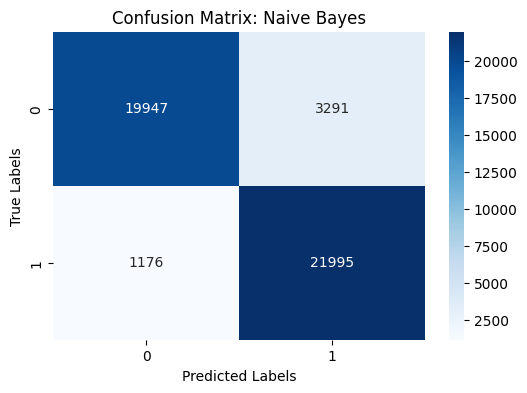

Naive Bayes AUC: 0.97


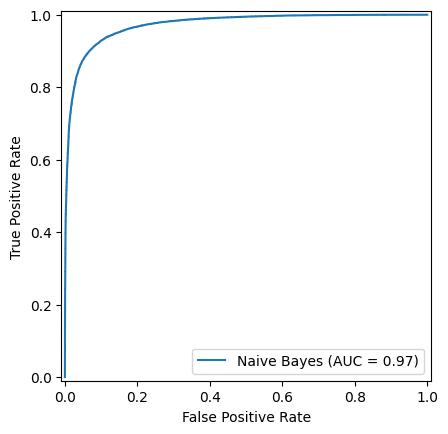

Naive Bayes Accuracy: 90.37%
              precision    recall  f1-score   support

           0       0.94      0.86      0.90     23238
           1       0.87      0.95      0.91     23171

    accuracy                           0.90     46409
   macro avg       0.91      0.90      0.90     46409
weighted avg       0.91      0.90      0.90     46409


Summary of Model Accuracies:
Logistic Regression: 93.51%
Naive Bayes: 90.37%


In [6]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary to store models and results
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_tfidf, y_train)  # Train the model

    # Save the trained model
    with open(f'{name.replace(" ", "_")}_model.pkl', 'wb') as f:
        pickle.dump(model, f)

    # Predict on the test set
    y_pred = model.predict(X_test_tfidf)

    # Compute Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"Confusion Matrix for {name}:\n{cm}")

    # Visualize Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.show()

    # Compute ROC Curve and AUC if applicable (binary classification required)
    if len(set(y_test)) == 2:  # Ensure binary classification
        y_prob = model.predict_proba(X_test_tfidf)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test_tfidf)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        print(f"{name} AUC: {roc_auc:.2f}")

        # Plot ROC Curve
        RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name=name).plot()
        plt.show()

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {accuracy * 100:.2f}%")
    print(classification_report(y_test, y_pred))

    # Store results
    results[name] = accuracy

# Display results summary
print("\nSummary of Model Accuracies:")
for name, acc in results.items():
    print(f"{name}: {acc * 100:.2f}%")


Evaluating error metrics for Logistic Regression...
Logistic Regression MAE: 0.0654, MSE: 0.0654, RMSE: 0.2558
Evaluating error metrics for Naive Bayes...
Naive Bayes MAE: 0.0963, MSE: 0.0963, RMSE: 0.3102


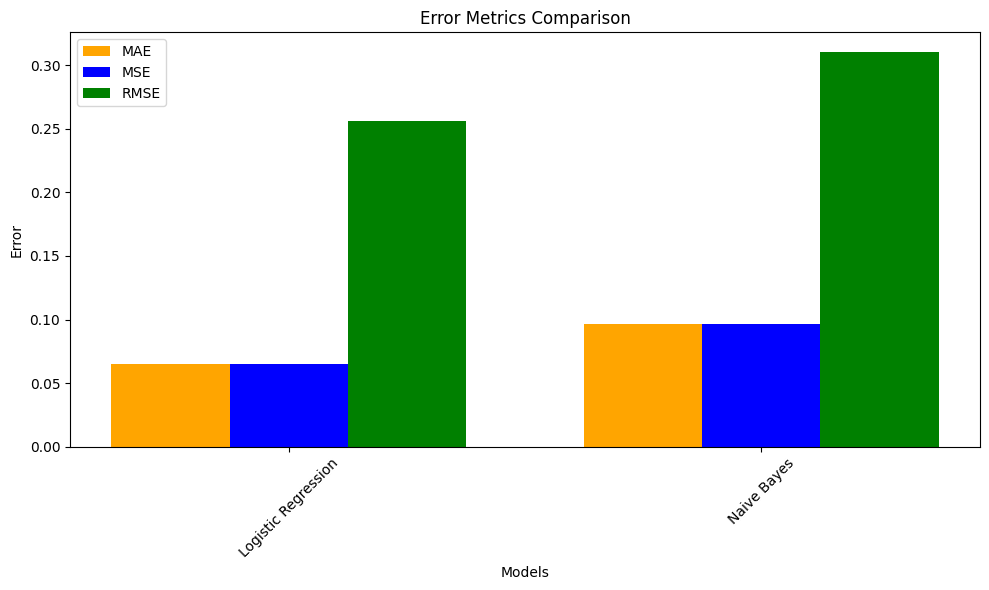

In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Dictionary to store error metrics
error_metrics = {}

# Loop through models
for name, model in models.items():
    print(f"Evaluating error metrics for {name}...")

    # Predict on the test set
    y_pred = model.predict(X_test_tfidf)

    # Calculate error metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Store error metrics
    error_metrics[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse}

    # Print metrics
    print(f"{name} MAE: {mae:.4f}, MSE: {mse:.4f}, RMSE: {rmse:.4f}")

# Plot the error metrics
mae_values = [metrics["MAE"] for metrics in error_metrics.values()]
mse_values = [metrics["MSE"] for metrics in error_metrics.values()]
rmse_values = [metrics["RMSE"] for metrics in error_metrics.values()]
model_names = list(error_metrics.keys())

x = np.arange(len(model_names))
width = 0.25

plt.figure(figsize=(10, 6))
plt.bar(x - width, mae_values, width, label='MAE', color='orange')
plt.bar(x, mse_values, width, label='MSE', color='blue')
plt.bar(x + width, rmse_values, width, label='RMSE', color='green')

plt.xlabel('Models')
plt.ylabel('Error')
plt.title('Error Metrics Comparison')
plt.xticks(x, model_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=066f56a5c299c34a450fbdcdc80b6c199c8ff0cf7f104e93b969d5897e8684e8
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime
